# KMV (2018) HANK — full thesis pipeline (step 1 + step 2)

One notebook that runs the whole analysis and writes every table and figure the
thesis needs.

**Step 1** — estimate the Kaplan–Moll–Violante two-component jump-drift earnings
process on GRID data (USA, FRA, GER), export a 75-state quarterly Markov chain.
**Step 2** — plug the chain into the Auclert–Rognlie–Straub one-asset HANK
(`shade-econ/annual-review`) + KMV stochastic death, re-calibrate, and reproduce
KMV's direct-vs-indirect monetary decomposition.

Framing: the thesis target is **Poland**; USA/FRA/GER are method validation.
Full decision logs: `DECISIONS.md` (step 1), `hank_step2/STEP2_LOG.md` (step 2).

### How to use

- Set `RUN_HEAVY = True` to re-run the SMM estimation (~3 h) and the step-2
  swaps (~15 min). Default `False` loads the committed results from
  `output/` and `hank_step2/results/` and just rebuilds the tables/figures
  (~2 min).
- Step 2 needs `shade-econ/annual-review` cloned **as a sibling of this repo**
  and `sequence-jacobian` from GitHub — see `README.md`. If they are missing the
  step-2 cells fall back to the saved JSON.
- Tables are written to `tables/`, figures to `figures/`.

## 0. Setup

In [1]:
import os, sys, json, subprocess
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm

# locate the repo root (the folder containing kmv_earnings/)
here = Path.cwd()
if not (here / "kmv_earnings").is_dir():
    for c in [here, *here.parents]:
        if (c / "kmv_earnings").is_dir():
            os.chdir(c); break
ROOT = Path.cwd()
assert (ROOT / "kmv_earnings").is_dir(), "run this from the repo (folder with kmv_earnings/)"

pd.set_option("display.float_format", lambda v: f"{v:.4g}")
FIGDIR = ROOT / "figures"; FIGDIR.mkdir(exist_ok=True)
TABDIR = ROOT / "tables";  TABDIR.mkdir(exist_ok=True)

RUN_HEAVY  = False            # True: re-run estimation (~3h) + step-2 swaps (~15min)
COUNTRIES  = ["USA", "FRA", "GER"]
AR   = ROOT.parent / "annual-review"      # shade-econ/annual-review, sibling of the repo
HS2  = ROOT / "hank_step2"

import kmv_earnings.simulate as sim
import kmv_earnings.estimate as est
import kmv_earnings.discretize as disc
import kmv_earnings.grid_loader as grid
import kmv_earnings.run as run

print("repo root :", ROOT)
print("RUN_HEAVY :", RUN_HEAVY)

repo root : C:\Users\kacpe\Desktop\makro research\magister HANK\kmv_grid_step1
RUN_HEAVY : False


---
# Part 1 — Step 1: the KMV earnings process

Pipeline: GRID statistics → 8 target moments → SMM estimation (differential
evolution + TikTak) → Table-2-style fit table → exported quarterly Markov chain.

## 1.1 Validate the simulator

Feed KMV's *published* Table 3 parameters through the simulator and compare the
moments with KMV's own model column — a correctness check of the engine
(parameters → moments), no fitting.

In [2]:
val, _ = run.build_table(sim.KMV_US_DATA_TARGETS, sim.KMV_TABLE3_PARAMS,
                         dict(n_workers=50_000, n_years_keep=36))
val.to_csv(TABDIR / "01_validate.csv", index=False)
print("KMV model column: 0.70  0.23  0.46  16.5  12.1  0.56  0.67  0.85")
val

KMV model column: 0.70  0.23  0.46  16.5  12.1  0.56  0.67  0.85


,Moment,Data,Model Estimated,Model Discretized
0,Variance: annual log earns,0.7,0.688,0.638
1,Variance: 1yr change,0.23,0.227,0.2
2,Variance: 5yr change,0.46,0.503,0.454
3,Kurtosis: 1yr change,17.8,14.55,13.93
4,Kurtosis: 5yr change,11.6,10.88,10.26
5,Frac 1yr change < 10%,0.54,0.547,0.648
6,Frac 1yr change < 20%,0.71,0.659,0.727
7,Frac 1yr change < 50%,0.86,0.84,0.87


## 1.2 GRID data and target moments

The 8 moments per country, computed on the **common 2001–2016 window** (all
three countries' overlap — `DECISIONS.md` §11). The small-change fractions are
interpolated from the 1-year-change percentile grid.

In [3]:
CSV = "data/Stats_20260720145608.csv"
raw = pd.read_csv(CSV)
coverage = (raw.groupby("country")["year"].agg(["min", "max", "count"])
               .rename(columns={"min": "first year", "max": "last year", "count": "n years"}))
display(coverage)

if RUN_HEAVY:
    for c in COUNTRIES:
        grid.save_targets(grid.targets_from_grid_stats_csv(CSV, c, year_range=(2001, 2016)),
                          f"targets/{c.lower()}_grid.json")

tgt = {c: json.load(open(f"targets/{c.lower()}_grid.json")) for c in COUNTRIES}
Tm = pd.DataFrame({c: {sim.MOMENT_LABELS[m]: tgt[c][m] for m in sim.MOMENT_ORDER} for c in COUNTRIES})
Tm.insert(0, "KMV (US, GKOS)", [sim.KMV_US_DATA_TARGETS[m] for m in sim.MOMENT_ORDER])
Tm.to_csv(TABDIR / "02_targets.csv")
Tm

,first year,last year,n years
country,,,
FRA,1991,2016,26
GER,2001,2016,16
USA,1998,2019,22


,"KMV (US, GKOS)",USA,FRA,GER
Variance: annual log earns,0.7,0.9557,0.4762,0.6452
Variance: 1yr change,0.23,0.3263,0.2066,0.1478
Variance: 5yr change,0.46,0.6123,0.3315,0.2849
Kurtosis: 1yr change,17.8,12.78,15.24,17.8
Kurtosis: 5yr change,11.6,8.829,11.4,11.21
Frac 1yr change < 10%,0.54,0.3874,0.519,0.611
Frac 1yr change < 20%,0.71,0.5882,0.7184,0.7876
Frac 1yr change < 50%,0.86,0.8106,0.8607,0.894


GRID-USA does not match KMV's published US column and is not expected to — KMV
target the GKOS SSA extract (~1978–2013); this is GRID's harmonised 2001–2016
sample, which is more volatile *and* less leptokurtic. See `DECISIONS.md` §12 —
this difference becomes a substantive finding in step 2.

## 1.3 SMM estimation — parameters and identification

Six parameters, eight moments; global search with **two** optimisers
(differential evolution and TikTak) as an identification cross-check. GER and USA
have the persistent-component decay `β₂` *pinned* to KMV's ergodic variance —
the 16-year / thin-tailed panels do not identify it (`DECISIONS.md` §8b).

In [4]:
if RUN_HEAVY:
    subprocess.check_call([sys.executable, "scripts/close_step1.py",
                           "--countries", *COUNTRIES, "--workers", "8"])

rep = {c: json.load(open(f"output/{c.lower()}/close_step1_report.json")) for c in COUNTRIES}

# --- estimated parameters (canonical), rows = params, cols = countries ---
par = pd.DataFrame({c: rep[c]["params_canonical"] for c in COUNTRIES}).loc[list(sim.PARAM_ORDER)]
pinned = {c: set(rep[c]["restricted"]["derived"]) | set(rep[c]["restricted"]["fixed"]) for c in COUNTRIES}
par.to_csv(TABDIR / "03_params_canonical.csv")
par_disp = par.map(lambda v: f"{v:.4g}")
for c in COUNTRIES:
    for p in pinned[c]:
        par_disp.loc[p, c] = par_disp.loc[p, c] + " (pinned)"
print("Estimated parameters (quarterly rates); 'pinned' = derived from KMV's ergodic variance")
display(par_disp)

Estimated parameters (quarterly rates); 'pinned' = derived from KMV's ergodic variance


,USA,FRA,GER
lambda1,0.2164,0.1914,0.158
beta1,2.933,4.266,5.339
sigma1,1.941,1.91,1.791
lambda2,0.0106,0.007049,0.01023
beta2,0.01361 (pinned),0.005153,0.006559 (pinned)
sigma2,1.529,1.092,1.08


In [5]:
# --- identification / diagnostics table ---
idr = []
for c in COUNTRIES:
    r = rep[c]
    idr.append(dict(
        country=c,
        canonical=r["winner"],
        OOS_f_DE=r["oos_f"]["de"], OOS_f_TikTak=r["oos_f"]["tiktak"],
        persistent_agree=r["persistent_agree"],
        any_param_at_bound=r["any_at_bound"],
        ergodic_sd_z2=r["ergodic_sd_z2"]["canonical"],
        KMV_ergodic_sd_z2=r["ergodic_sd_z2"]["kmv"],
        beta2_pinned=("beta2" in pinned[c]),
    ))
ID = pd.DataFrame(idr).set_index("country")
ID.to_csv(TABDIR / "04_identification.csv")
ID

,canonical,OOS_f_DE,OOS_f_TikTak,persistent_agree,any_param_at_bound,ergodic_sd_z2,KMV_ergodic_sd_z2,beta2_pinned
country,,,,,,,,
USA,DE,0.03299,0.03321,True,False,0.9541,0.9541,True
FRA,DE,0.001333,0.004899,True,False,0.9033,0.9541,False
GER,DE,0.03534,0.04077,True,False,0.9541,0.9541,True


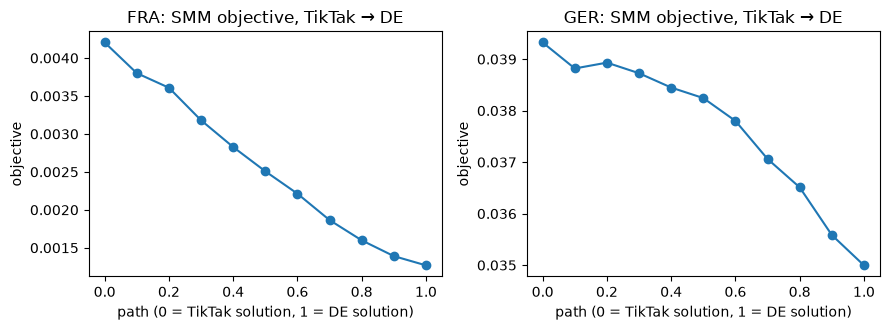

In [6]:
# --- DE vs TikTak: the objective along the straight line between the two solutions ---
# (FRA/GER: monotone downhill => one valley, not two basins => a convergence gap,
#  not an identification failure. DECISIONS.md section 9.)
ls = json.load(open("output/tiktak_line_scan.json"))
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
for i, c in enumerate(["FRA", "GER"]):
    s = ls[c]["line_scan"]
    ax[i].plot([p["a"] for p in s], [p["f"] for p in s], marker="o")
    ax[i].set_title(f"{c}: SMM objective, TikTak → DE")
    ax[i].set_xlabel("path (0 = TikTak solution, 1 = DE solution)")
    ax[i].set_ylabel("objective")
plt.tight_layout(); plt.savefig(FIGDIR / "01_de_vs_tiktak_linescan.png", dpi=130); plt.show()

## 1.4 Fit tables (KMV Table 2 style)

Per country: the 8 moments in the *Data*, *Model Estimated* (continuous
simulation at the estimate) and *Model Discretized* (the 75-state chain that
step 2 consumes) columns.

In [7]:
fit = {}
for c in COUNTRIES:
    t = pd.read_csv(f"output/{c.lower()}/table2.csv")
    fit[c] = t
    t.to_csv(TABDIR / f"05_fit_{c.lower()}.csv", index=False)
    print(f"\n=== {c} ===")
    display(t)


=== USA ===


,Moment,Data,Model Estimated,Model Discretized
0,Variance: annual log earns,0.9557,0.803,0.807
1,Variance: 1yr change,0.3263,0.323,0.237
2,Variance: 5yr change,0.6123,0.658,0.599
3,Kurtosis: 1yr change,12.78,12.36,15.07
4,Kurtosis: 5yr change,8.829,9.029,9.489
5,Frac 1yr change < 10%,0.3874,0.396,0.586
6,Frac 1yr change < 20%,0.5882,0.59,0.602
7,Frac 1yr change < 50%,0.8106,0.802,0.791



=== FRA ===


,Moment,Data,Model Estimated,Model Discretized
0,Variance: annual log earns,0.4762,0.476,0.479
1,Variance: 1yr change,0.2066,0.206,0.122
2,Variance: 5yr change,0.3315,0.332,0.263
3,Kurtosis: 1yr change,15.24,15.34,21.2
4,Kurtosis: 5yr change,11.4,11.41,13.18
5,Frac 1yr change < 10%,0.519,0.521,0.717
6,Frac 1yr change < 20%,0.7184,0.694,0.73
7,Frac 1yr change < 50%,0.8607,0.859,0.862



=== GER ===


,Moment,Data,Model Estimated,Model Discretized
0,Variance: annual log earns,0.6452,0.551,0.551
1,Variance: 1yr change,0.1478,0.142,0.085
2,Variance: 5yr change,0.2849,0.315,0.274
3,Kurtosis: 1yr change,17.8,17.91,25.22
4,Kurtosis: 5yr change,11.21,11.24,12.03
5,Frac 1yr change < 10%,0.611,0.614,0.76
6,Frac 1yr change < 20%,0.7876,0.757,0.846
7,Frac 1yr change < 50%,0.894,0.893,0.957


## 1.5 The exported chain

In [8]:
diag = []
for c in COUNTRIES:
    e  = np.loadtxt(f"output/{c.lower()}/income_process_grid.txt")
    z  = np.loadtxt(f"output/{c.lower()}/income_process_zgrid.txt")
    P  = np.loadtxt(f"output/{c.lower()}/income_process_P.txt")
    Q  = np.loadtxt(f"output/{c.lower()}/income_process_Q.txt")
    pi = np.loadtxt(f"output/{c.lower()}/income_process_pi.txt")
    diag.append(dict(
        country=c, n_states=len(e),
        P_rows_sum_1=bool(np.allclose(P.sum(1), 1)),
        mean_earnings=float(pi @ e),
        expm_Q_equals_P=bool(np.allclose(expm(Q), P, atol=1e-8)),
        ergodic_var_log_e=float(pi @ (np.log(e) - pi @ np.log(e)) ** 2),
    ))
CD = pd.DataFrame(diag).set_index("country")
CD.to_csv(TABDIR / "06_chain_diagnostics.csv")
print("Exported per country: income_process_{grid,zgrid,P,Q,pi}.txt")
CD

Exported per country: income_process_{grid,zgrid,P,Q,pi}.txt


,n_states,P_rows_sum_1,mean_earnings,expm_Q_equals_P,ergodic_var_log_e
country,,,,,
USA,75,True,1,True,1.191
FRA,75,True,1,True,1.04
GER,75,True,1,True,1.044


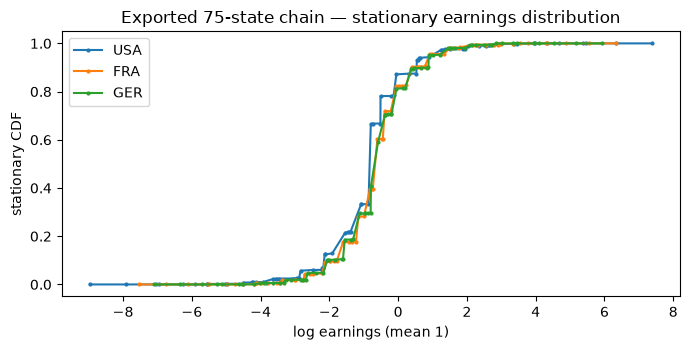

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for c in COUNTRIES:
    e  = np.loadtxt(f"output/{c.lower()}/income_process_grid.txt")
    pi = np.loadtxt(f"output/{c.lower()}/income_process_pi.txt")
    o = np.argsort(e)
    ax.plot(np.log(e[o]), np.cumsum(pi[o]), marker=".", ms=4, label=c)
ax.set_xlabel("log earnings (mean 1)"); ax.set_ylabel("stationary CDF")
ax.set_title("Exported 75-state chain — stationary earnings distribution"); ax.legend()
plt.tight_layout(); plt.savefig(FIGDIR / "02_chain_stationary_cdf.png", dpi=130); plt.show()

---
# Part 2 — Step 2: the one-asset HANK

The Auclert–Rognlie–Straub one-asset HANK (equity + bonds, no capital, sticky
prices; discount-factor heterogeneity) plus KMV stochastic death. Baseline first
(their KMV chain, unchanged), then our chains swapped in and re-calibrated.

In [10]:
step2_ready = AR.is_dir()
try:
    import sequence_jacobian  # noqa
    sj_ready = True
except ImportError:
    sj_ready = False
print("annual-review present:", step2_ready, " | sequence-jacobian importable:", sj_ready)

if RUN_HEAVY and step2_ready and sj_ready:
    subprocess.check_call([sys.executable, "baseline.py"], cwd=HS2)
    for c in COUNTRIES:
        subprocess.check_call([sys.executable, "swap_death.py", c.lower()], cwd=HS2)

base = json.load(open(HS2 / "results" / "baseline.json"))
swap = {c: json.load(open(HS2 / "results" / f"swap_death_{c.lower()}.json")) for c in COUNTRIES}

annual-review present: True  | sequence-jacobian importable: True


## 2.1 Baseline (ARS one-asset) — reproduced

Their KMV income process, their calibration. Verified against `Annual Review
main.ipynb` to floating-point precision.

In [11]:
hp = base["hh_params"]
print(f"discount types: beta_lo {hp['beta_hi']-hp['dbeta']:.4f}  beta_hi {hp['beta_hi']:.4f}"
      f"  omega(patient share) {hp['omega']:.2f}  beta_ave {hp['beta_ave']:.4f}")
print(f"frac hand-to-mouth {base['ha_wealth']['frac_at_borrowing_constraint']:.3f}   "
      f"top-10% wealth {base['ha_wealth']['top10_share']:.2f}   "
      f"MPC (labour) {base['mpc']['mpc_labor_impact']:.3f}   "
      f"MPC (unweighted) {base['mpc']['mpc_unweighted_impact']:.3f}")

sst = pd.DataFrame({m: {k: base["steady_state"][k][m] for k in ["ha", "ta", "ra"]}
                    for m in ["A", "C", "asset_mkt", "goods_mkt"]})
sst

discount types: beta_lo 0.9109  beta_hi 0.9988  omega(patient share) 0.49  beta_ave 0.9540
frac hand-to-mouth 0.279   top-10% wealth 0.75   MPC (labour) 0.200   MPC (unweighted) 0.289


,A,C,asset_mkt,goods_mkt
ha,20,0.8,2.197e-11,5.882e-07
ta,20,0.8,-9.912e-13,0
ra,20,0.8,-9.912e-13,0


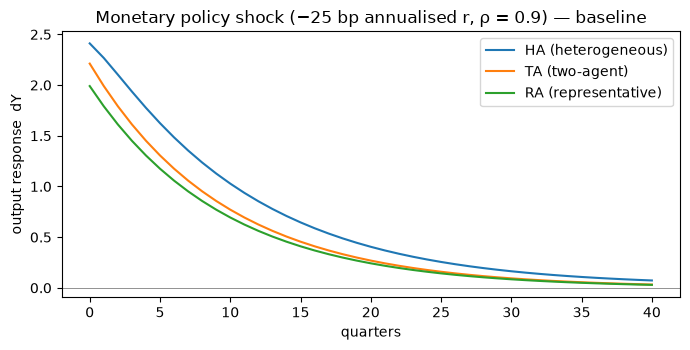

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for k, lab in [("ha", "HA (heterogeneous)"), ("ta", "TA (two-agent)"), ("ra", "RA (representative)")]:
    ax.plot(base["monetary_irf_Y"][k], label=lab)
ax.axhline(0, c="gray", lw=.6)
ax.set_xlabel("quarters"); ax.set_ylabel("output response  dY")
ax.set_title("Monetary policy shock (−25 bp annualised r, ρ = 0.9) — baseline"); ax.legend()
plt.tight_layout(); plt.savefig(FIGDIR / "03_baseline_monetary_irf.png", dpi=130); plt.show()

In [13]:
d0 = base["decomposition"]["year1_shares"]
DEC0 = pd.Series({"direct (r on bonds)": d0["direct_r"],
                  "indirect: labour income": d0["indirect_labor"],
                  "indirect: taxes": d0["indirect_tax"],
                  "indirect: capital gains": d0["indirect_cap_gains"]},
                 name="baseline, year-1 share")
print(DEC0.to_string(float_format=lambda x: f"{x:6.1%}"))
print("\nKMV (2018) Table 7 col 1: direct 19% | labour 51% | taxes 32% | capital gains -2%"
      "  => ~20 / 80 direct / indirect")

direct (r on bonds)        19.7%
indirect: labour income    41.8%
indirect: taxes            16.0%
indirect: capital gains    22.5%

KMV (2018) Table 7 col 1: direct 19% | labour 51% | taxes 32% | capital gains -2%  => ~20 / 80 direct / indirect


## 2.2 Our chains + KMV stochastic death

Swap our 75-state chain in, add Blanchard–Yaari perpetual youth (`ζ = 1/180`,
newborns at zero wealth), and re-calibrate the discount-factor grid
`(β_hi, dβ, ω)` to the same targets (`A = 20`, impact labour MPC `= 0.20`, SCF
Lorenz curve).

In [14]:
def brow(k):
    return dict(converged=True, beta_hi=hp["beta_hi"], beta_lo=hp["beta_hi"] - hp["dbeta"],
                dbeta=hp["dbeta"], omega=hp["omega"], beta_ave=hp["beta_ave"])
cal = {c: dict(converged=swap[c]["calibration"]["converged"],
               **{k: swap[c]["calibration"][k] for k in ["beta_hi", "beta_lo", "dbeta", "omega", "beta_ave"]})
       for c in COUNTRIES}
CAL = pd.DataFrame({**cal, "baseline (KMV chain)": brow(None)}).T
CAL.to_csv(TABDIR / "07_step2_calibration.csv")
CAL

,converged,beta_hi,beta_lo,dbeta,omega,beta_ave
USA,False,0.9901,0.9901,1.578e-09,0.592,0.9901
FRA,True,0.998,0.9047,0.09327,0.6987,0.9699
GER,True,0.9981,0.9316,0.06652,0.666,0.9759
baseline (KMV chain),True,0.9988,0.9109,0.08786,0.4903,0.954


In [15]:
def srow(c):
    s = swap[c]
    return dict(converged=s["calibration"]["converged"],
                frac_HtM=s["ha_wealth"]["frac_at_borrowing_constraint"],
                top10_wealth=s["ha_wealth"]["top10_share"],
                MPC_labour=s["mpc"]["mpc_labor_impact"],
                MPC_unweighted=s["mpc"]["mpc_unweighted_impact"],
                monetary_dY_impact=s["monetary_irf_Y_impact"],
                monetary_dY_cum40=s["monetary_irf_Y_cum40"])
SS = pd.DataFrame({c: srow(c) for c in COUNTRIES}).T
SS.loc["baseline"] = dict(converged=True,
    frac_HtM=base["ha_wealth"]["frac_at_borrowing_constraint"],
    top10_wealth=base["ha_wealth"]["top10_share"],
    MPC_labour=base["mpc"]["mpc_labor_impact"],
    MPC_unweighted=base["mpc"]["mpc_unweighted_impact"],
    monetary_dY_impact=base["monetary_irf_Y_impact"]["ha"],
    monetary_dY_cum40=base["monetary_irf_Y_cum40"]["ha"])
SS.to_csv(TABDIR / "08_step2_steadystate.csv")
SS

,converged,frac_HtM,top10_wealth,MPC_labour,MPC_unweighted,monetary_dY_impact,monetary_dY_cum40
USA,False,0.01086,0.7966,0.02934,0.05752,1.854,21.33
FRA,True,0.2249,0.7603,0.2,0.2561,2.294,23.58
GER,True,0.2495,0.758,0.2,0.2739,2.325,24.03
baseline,True,0.279,0.7533,0.2,0.2889,2.411,28.26


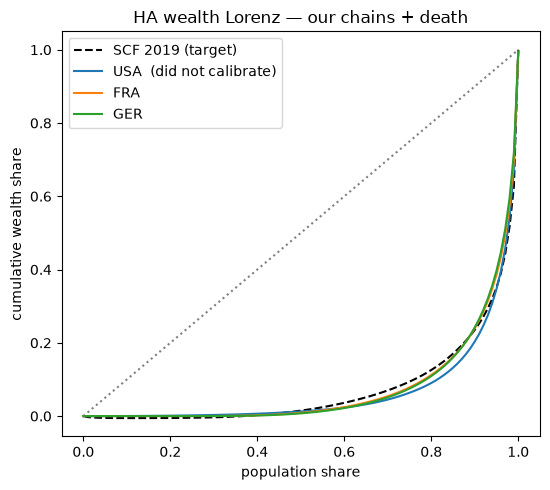

In [16]:
p = np.arange(101) / 100
lrf = AR / "inputs" / "lorenz_nw_scf_2019.raw"
fig, ax = plt.subplots(figsize=(5.6, 5))
ax.plot([0, 1], [0, 1], ":", c="gray")
if lrf.exists():
    lr = np.loadtxt(str(lrf), delimiter=",")
    ax.plot(p, [np.interp(x, lr[:, 0], lr[:, 1]) for x in p], "--", c="k", label="SCF 2019 (target)")
for c in COUNTRIES:
    lz = swap[c]["ha_wealth"].get("lorenz")
    if lz:
        lab = c + ("" if swap[c]["calibration"]["converged"] else "  (did not calibrate)")
        ax.plot(p, lz, label=lab)
ax.set_xlabel("population share"); ax.set_ylabel("cumulative wealth share")
ax.set_title("HA wealth Lorenz — our chains + death"); ax.legend()
plt.tight_layout(); plt.savefig(FIGDIR / "04_step2_wealth_lorenz.png", dpi=130); plt.show()

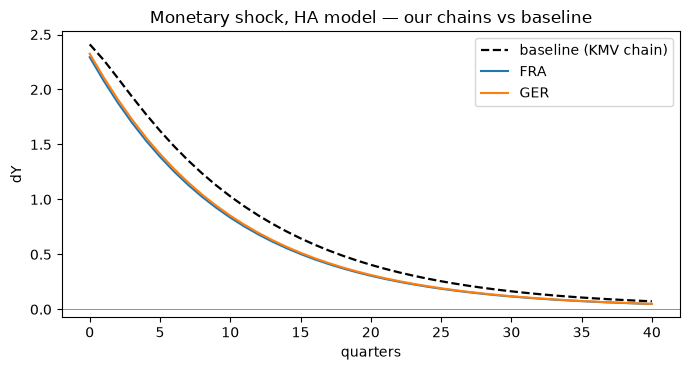

In [17]:
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(base["monetary_irf_Y"]["ha"], "k--", lw=1.6, label="baseline (KMV chain)")
for c in COUNTRIES:
    if swap[c]["calibration"]["converged"]:
        ax.plot(swap[c]["monetary_irf_Y"], label=c)
ax.axhline(0, c="gray", lw=.6)
ax.set_xlabel("quarters"); ax.set_ylabel("dY")
ax.set_title("Monetary shock, HA model — our chains vs baseline"); ax.legend()
plt.tight_layout(); plt.savefig(FIGDIR / "05_step2_monetary_irf.png", dpi=130); plt.show()

## 2.3 The headline: direct vs indirect

The result the thesis replicates — in the HANK model most of the output response
to a monetary shock is **indirect** (general-equilibrium income effects), not the
direct interest-rate channel.

In [18]:
def drow(c):
    y = swap[c]["decomposition"]["year1"]
    return dict(converged=swap[c]["calibration"]["converged"],
                direct=y["direct_r"], indirect=y["indirect_total"],
                ind_labour=y["indirect_labor"], ind_taxes=y["indirect_tax"],
                ind_capital_gains=y["indirect_cap_gains"],
                identity_residual=swap[c]["decomposition_check"]["rel"])
DEC = pd.DataFrame({c: drow(c) for c in COUNTRIES}).T
bd = base["decomposition"]["year1_shares"]
DEC.loc["baseline"] = dict(converged=True, direct=bd["direct_r"],
    indirect=bd["indirect_labor"] + bd["indirect_tax"] + bd["indirect_cap_gains"],
    ind_labour=bd["indirect_labor"], ind_taxes=bd["indirect_tax"],
    ind_capital_gains=bd["indirect_cap_gains"], identity_residual=0.0)
DEC.loc["KMV (2018) Table 7"] = dict(converged=True, direct=0.19, indirect=0.81,
    ind_labour=0.51, ind_taxes=0.32, ind_capital_gains=-0.02, identity_residual=np.nan)
DEC.to_csv(TABDIR / "09_decomposition.csv")
DEC

,converged,direct,indirect,ind_labour,ind_taxes,ind_capital_gains,identity_residual
USA,False,0.3125,0.704,0.1998,0.09412,0.4101,0.09141
FRA,True,0.2555,0.7445,0.329,0.1402,0.2754,9.982e-07
GER,True,0.2395,0.7605,0.345,0.1447,0.2708,1.469e-06
baseline,True,0.1965,0.8035,0.4182,0.1598,0.2255,0
KMV (2018) Table 7,True,0.19,0.81,0.51,0.32,-0.02,NaN


**FRA and GER** reproduce "indirect dominates" (~75% indirect vs KMV's 81% and
the baseline's 80%); the direct share runs a few points above KMV's 19% because
our estimated transitory/persistent structure passes less of the equilibrium
wage response through to consumption.

**USA does not calibrate** — with the GRID-USA chain the aggregate MPC collapses
to ≈ 0.03 no matter the discount factor (thin tail: `kurt Δ1y` 12.8 vs KMV's
17.8; more persistent transitory component). The US validation therefore runs on
KMV's own chain (the §2.1 baseline, which reproduces the 20/80 split); the
GRID-USA chain is reported as a sensitivity whose *failure to support the
mechanism* is itself the finding (`hank_step2/STEP2_LOG.md` §S5, `DECISIONS.md`
§12).

---
# Part 3 — Consolidated outputs

In [19]:
print("Tables written to  tables/ :")
for f in sorted(TABDIR.glob("*.csv")):
    print("  ", f.name)
print("\nFigures written to figures/ :")
for f in sorted(FIGDIR.glob("*.png")):
    print("  ", f.name)
print("\nExported chains  : output/<country>/income_process_{grid,zgrid,P,Q,pi}.txt")
print("Decision logs    : DECISIONS.md (step 1), hank_step2/STEP2_LOG.md (step 2)")
print("Open for the thesis: build two-asset only if the Polish chain is GRID-USA-shaped")
print("                     (kurt d1y well below ~15 and/or beta1 <~ 3) -- see DECISIONS.md open list")

Tables written to  tables/ :
   01_validate.csv
   02_targets.csv
   03_params_canonical.csv
   04_identification.csv
   05_fit_fra.csv
   05_fit_ger.csv
   05_fit_usa.csv
   06_chain_diagnostics.csv
   07_step2_calibration.csv
   08_step2_steadystate.csv
   09_decomposition.csv

Figures written to figures/ :
   01_de_vs_tiktak_linescan.png
   02_chain_stationary_cdf.png
   03_baseline_monetary_irf.png
   04_step2_wealth_lorenz.png
   05_step2_monetary_irf.png

Exported chains  : output/<country>/income_process_{grid,zgrid,P,Q,pi}.txt
Decision logs    : DECISIONS.md (step 1), hank_step2/STEP2_LOG.md (step 2)
Open for the thesis: build two-asset only if the Polish chain is GRID-USA-shaped
                     (kurt d1y well below ~15 and/or beta1 <~ 3) -- see DECISIONS.md open list
